## **Predicting brain stroke risk using hybrid machine learning and deep learning models**

Dataset Link: https://www.kaggle.com/datasets/jillanisofttech/brain-stroke-dataset

#### **Dataset Download**

**Google Colab**

```python
!pip install -q kaggle

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d jillanisofttech/brain-stroke-dataset

!unzip brain-stroke-dataset.zip
```

**VS Code (Recommended)**

In [2]:
import kaggle

dataset_link = "jillanisofttech/brain-stroke-dataset"

kaggle.api.authenticate()

kaggle.api.dataset_download_files(dataset_link, path=".", unzip=True)

print(f"{dataset_link} successfully downloaded")

Dataset URL: https://www.kaggle.com/datasets/jillanisofttech/brain-stroke-dataset
jillanisofttech/brain-stroke-dataset successfully downloaded


In [3]:
import os
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

#### **Loading Dataset**

In [4]:
stroke_df = pd.read_csv('brain_stroke.csv')
stroke_df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


#### **Exploratory Data Analysis**

In [5]:
df = stroke_df.copy()

df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


**Unique value count in each column**

In [6]:
for c in df.columns:
    print(f"{c} has {df[c].nunique()}")

gender has 2
age has 104
hypertension has 2
heart_disease has 2
ever_married has 2
work_type has 4
Residence_type has 2
avg_glucose_level has 3895
bmi has 342
smoking_status has 4
stroke has 2


In [7]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Dataset has 4981 rows and 11 columns


**Gender column data mapping**

In [8]:
binary_cols = ['hypertension','heart_disease', 'stroke']

for col in binary_cols:
    df[col] = df[col].map({0:"No", 1:"Yes"})

In [9]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,No,Yes,Yes,Private,Urban,228.69,36.6,formerly smoked,Yes
1,Male,80.0,No,Yes,Yes,Private,Rural,105.92,32.5,never smoked,Yes
2,Female,49.0,No,No,Yes,Private,Urban,171.23,34.4,smokes,Yes
3,Female,79.0,Yes,No,Yes,Self-employed,Rural,174.12,24.0,never smoked,Yes
4,Male,81.0,No,No,Yes,Private,Urban,186.21,29.0,formerly smoked,Yes


**Gender distribution for TenYearCHD**

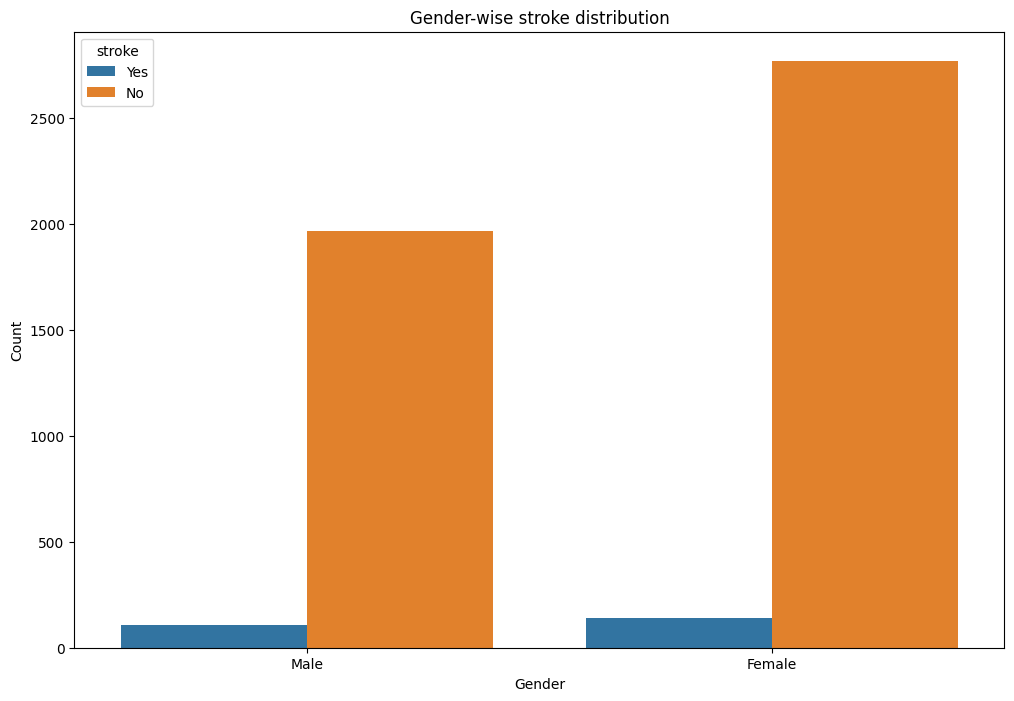

In [10]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, x='gender', hue='stroke')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender-wise stroke distribution")
plt.show()

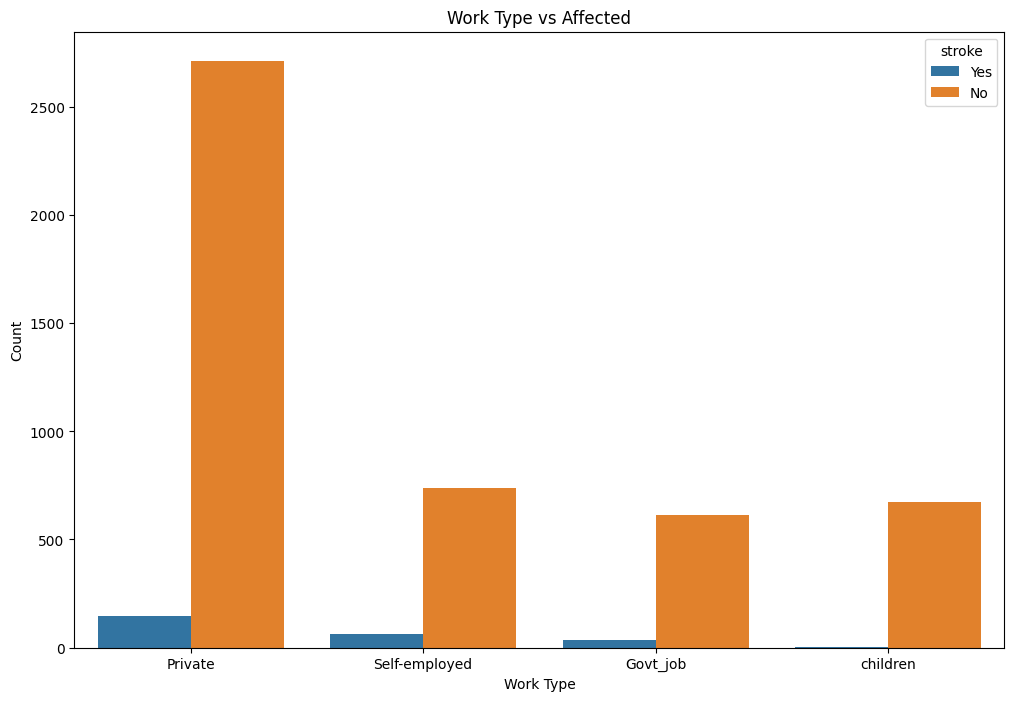

In [11]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='work_type', hue='stroke')
plt.xlabel("Work Type")
plt.ylabel("Count")
plt.title("Work Type vs Affected")
plt.show()

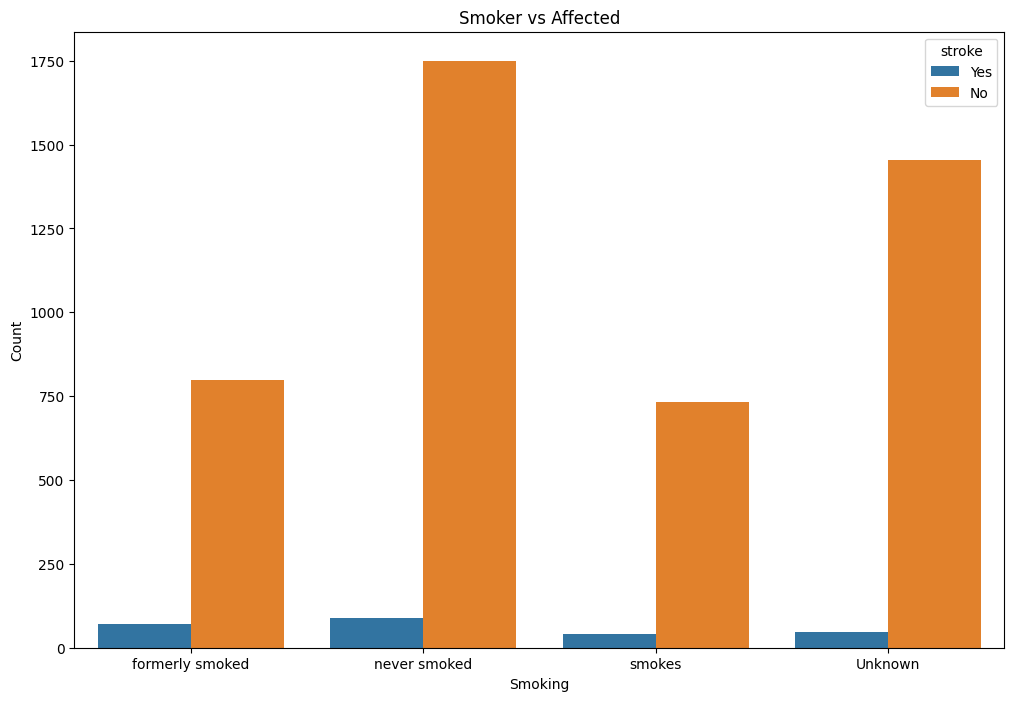

In [12]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='smoking_status', hue='stroke')
plt.xlabel("Smoking")
plt.ylabel("Count")
plt.title("Smoker vs Affected")
plt.show()

**Has Blood Pressure**

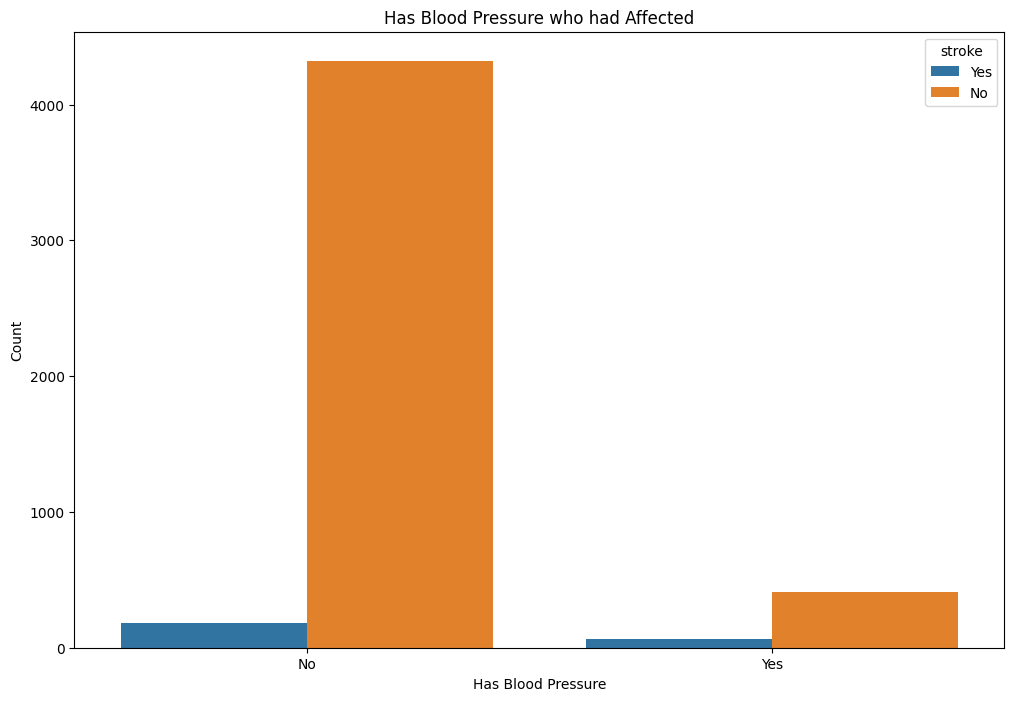

In [12]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='hypertension', hue='stroke')
plt.xlabel("Has Blood Pressure")
plt.ylabel("Count")
plt.title("Has Blood Pressure who had Affected")
plt.show()

**Has Stroke vs Affected**

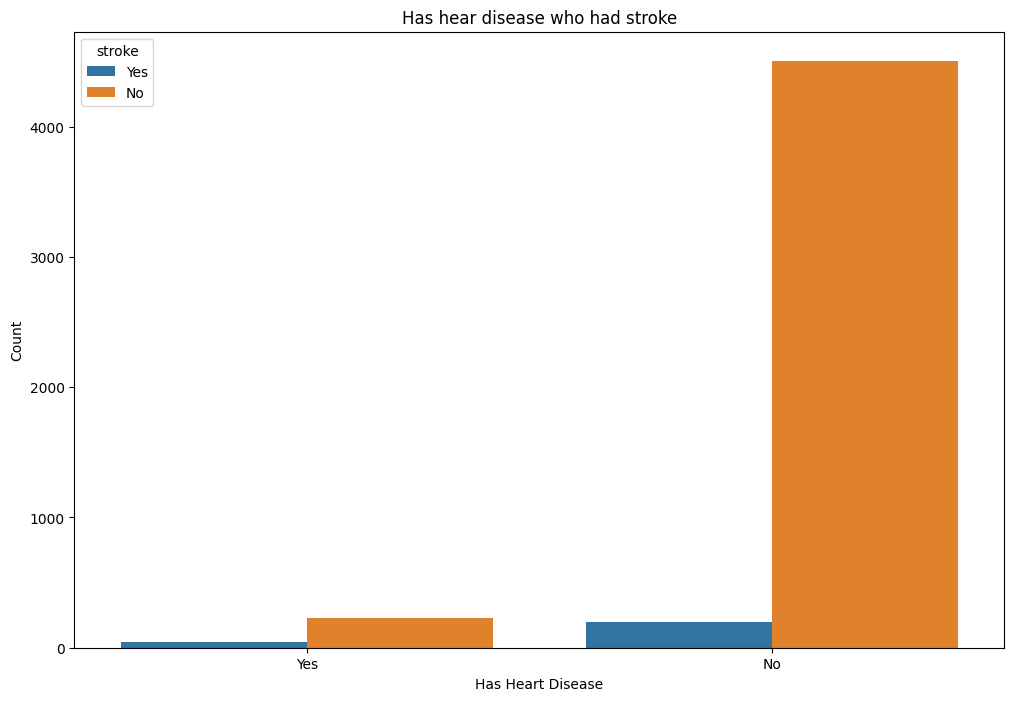

In [13]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='heart_disease', hue='stroke')
plt.xlabel("Has Heart Disease")
plt.ylabel("Count")
plt.title("Has hear disease who had stroke")
plt.show()

In [14]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,No,Yes,Yes,Private,Urban,228.69,36.6,formerly smoked,Yes
1,Male,80.0,No,Yes,Yes,Private,Rural,105.92,32.5,never smoked,Yes
2,Female,49.0,No,No,Yes,Private,Urban,171.23,34.4,smokes,Yes
3,Female,79.0,Yes,No,Yes,Self-employed,Rural,174.12,24.0,never smoked,Yes
4,Male,81.0,No,No,Yes,Private,Urban,186.21,29.0,formerly smoked,Yes


In [15]:
stroke_df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


#### **Preprocessing**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, chi2

In [17]:
stroke_data = stroke_df.copy()

**Basic Info**

In [18]:
print("Shape:", stroke_data.shape)
print("\nMissing values:\n", stroke_data.isnull().sum())
print("\nClass distribution:\n", stroke_data['stroke'].value_counts())

Shape: (4981, 11)

Missing values:
 gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Class distribution:
 stroke
0    4733
1     248
Name: count, dtype: int64


**Feature Engineering**

In [19]:
cat_cols = ['gender', 'ever_married', 'work_type', 
            'Residence_type', 'smoking_status']

data = pd.get_dummies(stroke_data, columns=cat_cols, drop_first=True)

In [20]:
# Age group
data['age_group'] = pd.cut(data['age'], 
                           bins=[0, 30, 45, 60, 100],
                           labels=[0,1,2,3])

# Glucose risk
data['glucose_risk'] = np.where(data['avg_glucose_level'] > 140, 1, 0)

# BMI category
data['bmi_category'] = pd.cut(data['bmi'],
                              bins=[0,18.5,25,30,100],
                              labels=[0,1,2,3])

In [21]:
data['age_group'] = data['age_group'].astype(int)
data['bmi_category'] = data['bmi_category'].astype(int)

In [ ]:
X = data.drop('stroke', axis=1)
y = data['stroke']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Feature Selection**

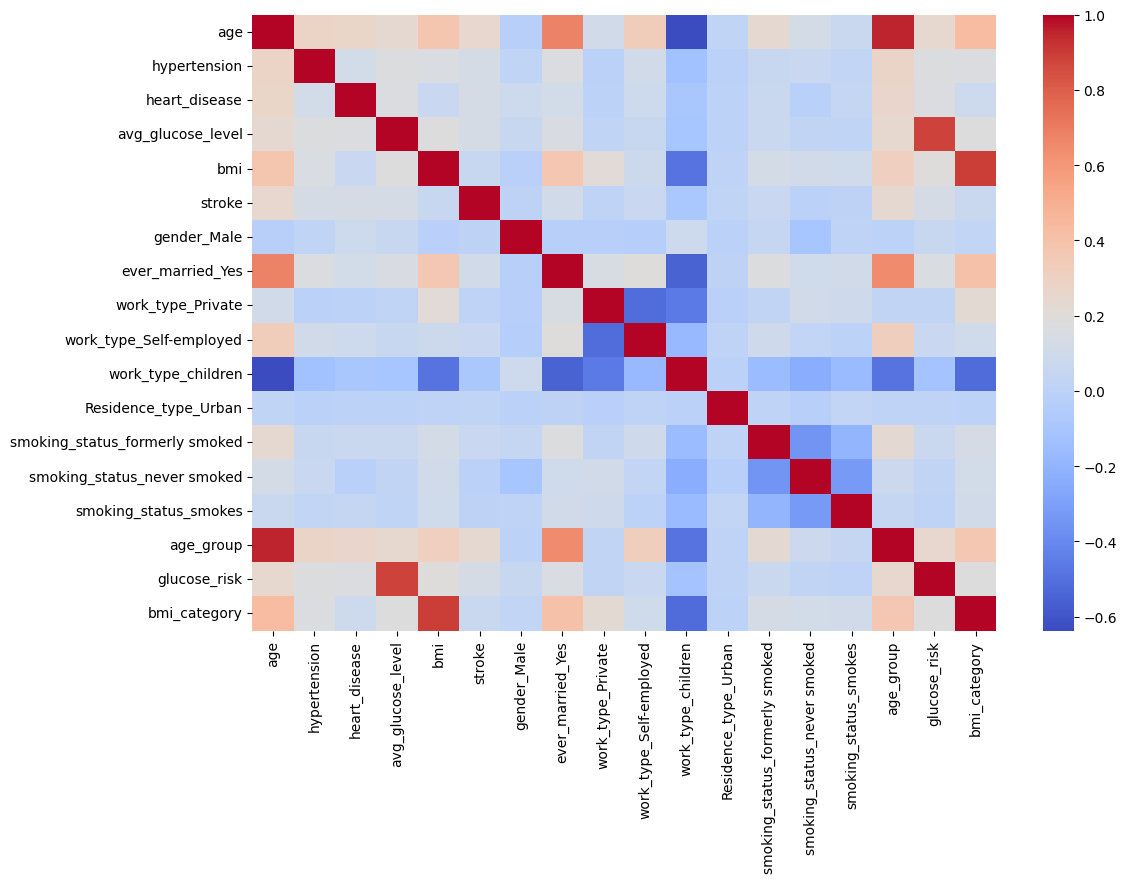

In [23]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.show()

In [ ]:
selector = SelectKBest(score_func=chi2, k=15)
X_new = selector.fit_transform(abs(X), y)

selected_features = X.columns[selector.get_support()]
print(selected_features)

X = X[selected_features]

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'ever_married_Yes', 'work_type_Private', 'work_type_Self-employed',
       'work_type_children', 'Residence_type_Urban',
       'smoking_status_formerly smoked', 'smoking_status_smokes', 'age_group',
       'glucose_risk', 'bmi_category'],
      dtype='str')


#### **Train, Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [26]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (3984, 15)
Testing shape: (997, 15)


#### **Handling Class Imbalance**

In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())

stroke
0    3786
1    3786
Name: count, dtype: int64


#### **Machine Learning Models**

**Logistic Regression**

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

[[803 144]
 [ 26  24]]
              precision    recall  f1-score   support

           0       0.97      0.85      0.90       947
           1       0.14      0.48      0.22        50

    accuracy                           0.83       997
   macro avg       0.56      0.66      0.56       997
weighted avg       0.93      0.83      0.87       997



In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

In [33]:
print(f"Accuracy of Logistic Regression is {lr_accuracy:.3f}")
print(f"Recall of Logistic Regression is {lr_recall:.3f}")
print(f"Precision of Logistic Regression is {lr_precision:.3f}")
print(f"F1 Score of Logistic Regression is {lr_f1:.3f}")

Accuracy of Logistic Regression is 0.829
Recall of Logistic Regression is 0.480
Precision of Logistic Regression is 0.143
F1 Score of Logistic Regression is 0.220


**Random Forest Classifier**

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[910  37]
 [ 43   7]]
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       947
           1       0.16      0.14      0.15        50

    accuracy                           0.92       997
   macro avg       0.56      0.55      0.55       997
weighted avg       0.91      0.92      0.92       997



In [35]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

In [36]:
print(f"Accuracy of Logistic Regression is {rf_accuracy:.3f}")
print(f"Recall of Logistic Regression is {rf_recall:.3f}")
print(f"Precision of Logistic Regression is {rf_precision:.3f}")
print(f"F1 Score of Logistic Regression is {rf_f1:.3f}")

Accuracy of Logistic Regression is 0.920
Recall of Logistic Regression is 0.140
Precision of Logistic Regression is 0.159
F1 Score of Logistic Regression is 0.149


#### **Deep Learning Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import roc_auc_score, classification_report


In [37]:
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [40]:
# Convert all columns to numeric
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# Convert target also
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

**Simple ANN**

In [ ]:
ven_model = Sequential()

ven_model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
ven_model.add(Dropout(0.3))
ven_model.add(Dense(32, activation='relu'))
ven_model.add(Dense(1, activation='sigmoid'))

ven_model.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

ven_history = ven_model.fit(X_train, y_train,
                      epochs=30,
                      batch_size=32,
                      validation_split=0.2)

ven_model.evaluate(X_test, y_test)

Epoch 1/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5869 - loss: 2.0695 - val_accuracy: 0.6363 - val_loss: 0.6275
Epoch 2/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6634 - loss: 0.7413 - val_accuracy: 0.7215 - val_loss: 0.5910
Epoch 3/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6957 - loss: 0.5952 - val_accuracy: 0.6805 - val_loss: 0.6707
Epoch 4/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7003 - loss: 0.5594 - val_accuracy: 0.6779 - val_loss: 0.7140
Epoch 5/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7301 - loss: 0.5100 - val_accuracy: 0.0997 - val_loss: 1.1386
Epoch 6/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7421 - loss: 0.5040 - val_accuracy: 0.7149 - val_loss: 0.6547
Epoch 7/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7500 - loss: 0.4836 - val_accuracy: 0.8112 - val_loss: 0.5089
Epoch 8/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7537 - loss: 0.4773 - val_accuracy: 0.

[0.314946711063385, 0.8395185470581055]

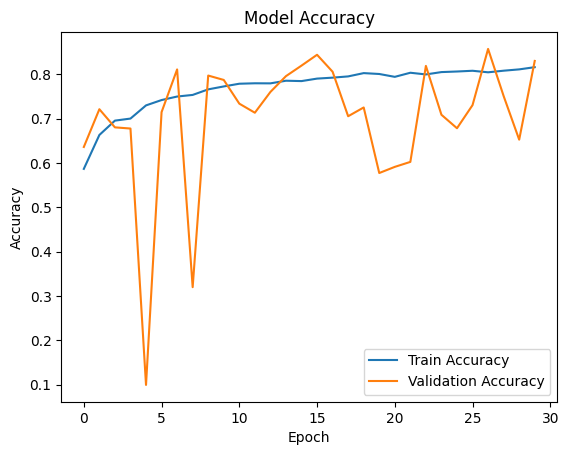

In [44]:
plt.figure()

plt.plot(ven_history.history['accuracy'])
plt.plot(ven_history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train Accuracy','Validation Accuracy'])

plt.show()

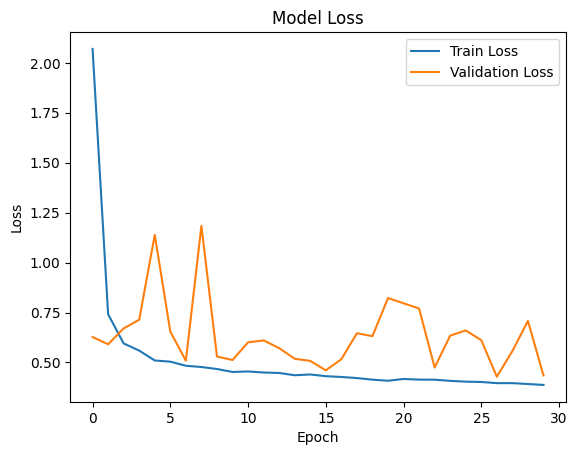

In [45]:
plt.figure()

plt.plot(ven_history.history['loss'])
plt.plot(ven_history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train Loss','Validation Loss'])

plt.show()

In [47]:
y_pred_prob = ven_model.predict(X_test)

y_pred_ven = (y_pred_prob > 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [51]:
ven_accuracy = accuracy_score(y_test, y_pred_ven)
ven_precision = precision_score(y_test, y_pred_ven)
ven_recall = recall_score(y_test, y_pred_ven)
ven_f1 = f1_score(y_test, y_pred_ven)

print(f"Accuracy : {ven_accuracy:.3f}")
print(f"Precision: {ven_precision:.3f}")
print(f"Recall   : {ven_recall:.3f}")
print(f"F1 Score : {ven_f1:.3f}")

Accuracy : 0.840
Precision: 0.143
Recall   : 0.440
F1 Score : 0.216


**Deep ANN**

In [52]:
deep_model = Sequential()

deep_model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
deep_model.add(Dropout(0.4))
deep_model.add(Dense(64, activation='relu'))
deep_model.add(Dropout(0.3))
deep_model.add(Dense(32, activation='relu'))
deep_model.add(Dense(1, activation='sigmoid'))

deep_model.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

deep_history = deep_model.fit(X_train, y_train,
                      epochs=50,
                      batch_size=32,
                      validation_split=0.2)

deep_model.evaluate(X_test, y_test)

Epoch 1/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5628 - loss: 1.3879 - val_accuracy: 0.0000e+00 - val_loss: 1.0258
Epoch 2/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6208 - loss: 0.6972 - val_accuracy: 0.4007 - val_loss: 0.7274
Epoch 3/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6627 - loss: 0.6031 - val_accuracy: 0.5459 - val_loss: 0.7261
Epoch 4/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6736 - loss: 0.5746 - val_accuracy: 0.6165 - val_loss: 0.7095
Epoch 5/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6937 - loss: 0.5508 - val_accuracy: 0.3630 - val_loss: 0.8002
Epoch 6/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6980 - loss: 0.5417 - val_accuracy: 0.3538 - val_loss: 0.7985
Epoch 7/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7081 - loss: 0.5243 - val_accuracy: 0.3314 - val_loss: 0.8558
Epoch 8/50
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7263 - loss: 0.5116 - val_accuracy

[0.22630757093429565, 0.9368104338645935]

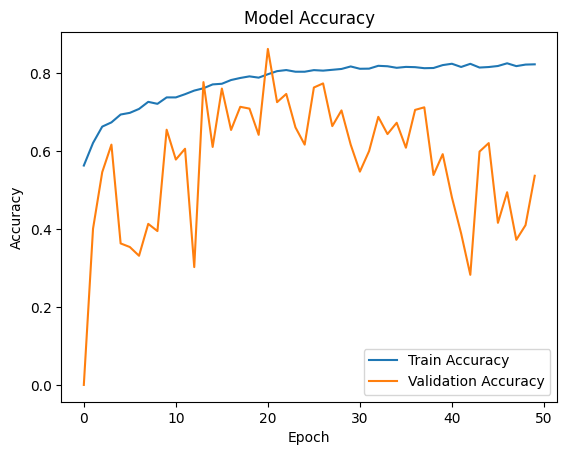

In [53]:
plt.figure()

plt.plot(deep_history.history['accuracy'])
plt.plot(deep_history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train Accuracy','Validation Accuracy'])

plt.show()

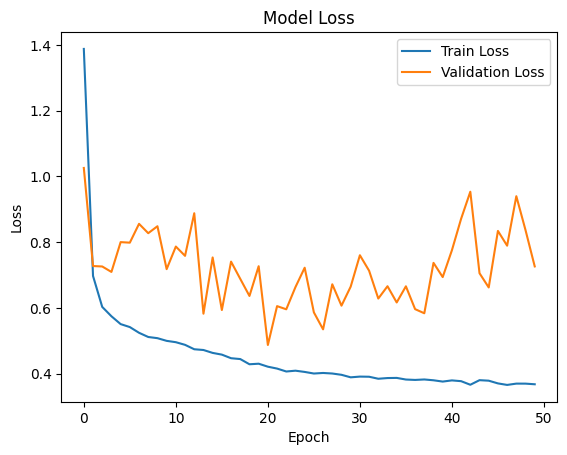

In [54]:
plt.figure()

plt.plot(deep_history.history['loss'])
plt.plot(deep_history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train Loss','Validation Loss'])

plt.show()

In [55]:
y_pred_prob = deep_model.predict(X_test)

y_pred_deep = (y_pred_prob > 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [56]:
deep_accuracy = accuracy_score(y_test, y_pred_deep)
deep_precision = precision_score(y_test, y_pred_deep)
deep_recall = recall_score(y_test, y_pred_deep)
deep_f1 = f1_score(y_test, y_pred_deep)

print(f"Accuracy : {deep_accuracy:.3f}")
print(f"Precision: {deep_precision:.3f}")
print(f"Recall   : {deep_recall:.3f}")
print(f"F1 Score : {deep_f1:.3f}")

Accuracy : 0.937
Precision: 0.067
Recall   : 0.020
F1 Score : 0.031


In [ ]:
print("LR AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))
print("RF AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

dl_pred1 = ven_model.predict(X_test)
dl_pred2 = deep_model.predict(X_test)

print("ANN1 AUC:", roc_auc_score(y_test, dl_pred1))
print("ANN2 AUC:", roc_auc_score(y_test, dl_pred2))

LR AUC: 0.7337697993664203
RF AUC: 0.820285110876452
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
ANN1 AUC: 0.7808025343189018
ANN2 AUC: 0.7729672650475184


#### **Comparison**

In [58]:
models = ['Logistic Regression', 'Random Forest Classifier', 'Simple ANN', 'Deep ANN']

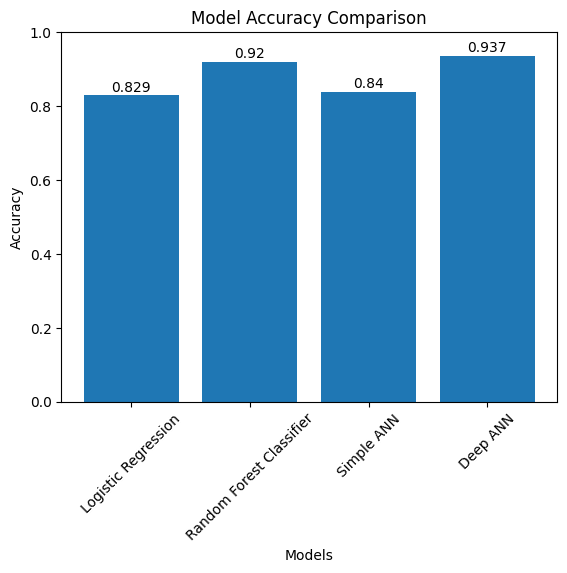

In [62]:
plt.figure()

accuracy_scores = [lr_accuracy, rf_accuracy, ven_accuracy, deep_accuracy]
bars = plt.bar(models, accuracy_scores)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.xticks(rotation=45)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval,3), ha='center')

plt.show()

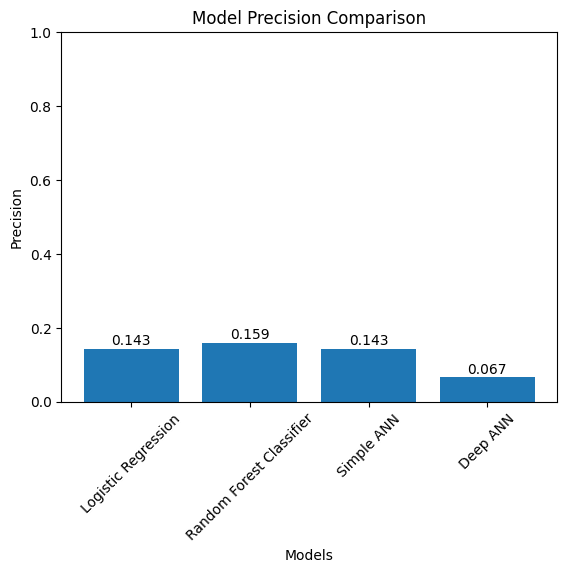

In [61]:
plt.figure()

precision_scores = [lr_precision, rf_precision, ven_precision, deep_precision]
bars = plt.bar(models, precision_scores)

plt.title("Model Precision Comparison")
plt.xlabel("Models")
plt.ylabel("Precision")
plt.xticks(rotation=45)
plt.ylim(0,1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval,3), ha='center')

plt.show()

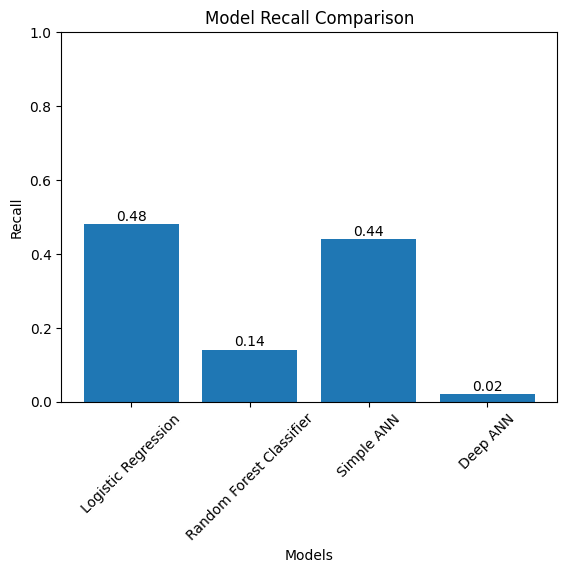

In [63]:
plt.figure()

recall_scores = [lr_recall, rf_recall, ven_recall, deep_recall]
bars = plt.bar(models, recall_scores)

plt.title("Model Recall Comparison")
plt.xlabel("Models")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.ylim(0,1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval,3), ha='center')

plt.show()

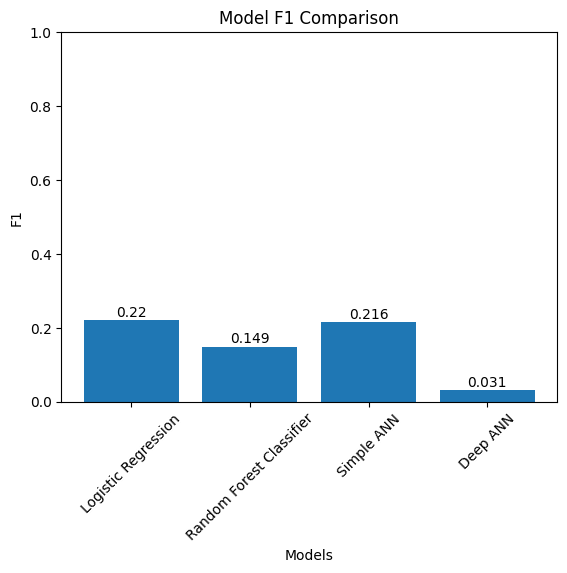

In [64]:
plt.figure()

f1_scores = [lr_f1, rf_f1, ven_f1, deep_f1]
bars = plt.bar(models, f1_scores)

plt.title("Model F1 Comparison")
plt.xlabel("Models")
plt.ylabel("F1")
plt.xticks(rotation=45)
plt.ylim(0,1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval,3), ha='center')

plt.show()

#### **Fine Tuning Models**